In [30]:
import pandas as pd

#read
df=pd.read_csv("insurance_claims.csv", parse_dates=["policy_bind_date", "incident_date"], index_col="policy_number")

#check duplicates
df.duplicated().sum() 
df['authorities_contacted']=df['authorities_contacted'].fillna("Police")

#ensure consistency on column names
rename ={'capital-gains':'capital_gains','capital-loss': 'capital_loss'}
df.rename(columns=rename, inplace=True)

#Rename Strings
df["collision_type"]=df["collision_type"].apply(lambda x: "No Collision" if str(x)=="?" else x)
df["police_report_available"]=df["police_report_available"].apply(lambda x: "Unknown" if str(x)=="?" else x)
df["property_damage"]=df["property_damage"].apply(lambda x: "Unknown" if str(x)=="?" else x)


# drop column as 100% nan-values
# drop umbrella limits as 80% of values are zeros, std = 1.1 Mio
df.drop(['months_as_customer',  'umbrella_limit',  'total_claim_amount', '_c39'],axis=1,inplace= True)
df.head().T


policy_number,521585,342868,687698,227811,367455
age,48,42,29,41,44
policy_bind_date,2014-10-17 00:00:00,2006-06-27 00:00:00,2000-09-06 00:00:00,1990-05-25 00:00:00,2014-06-06 00:00:00
policy_state,OH,IN,OH,IL,IL
policy_csl,250/500,250/500,100/300,250/500,500/1000
policy_deductable,1000,2000,2000,2000,1000
policy_annual_premium,1406.91,1197.22,1413.14,1415.74,1583.91
insured_zip,466132,468176,430632,608117,610706
insured_sex,MALE,MALE,FEMALE,FEMALE,MALE
insured_education_level,MD,MD,PhD,PhD,Associate
insured_occupation,craft-repair,machine-op-inspct,sales,armed-forces,sales


In [31]:
from sklearn.preprocessing import LabelEncoder
LabelEnc = LabelEncoder()
#label encode fraud_reported
df['fraud_reported'] = LabelEnc.fit_transform(df['fraud_reported'])
#label encode policy_state
df['policy_state'] = LabelEnc.fit_transform(df['policy_state'])
#label encode insured_sex
df['insured_sex']=LabelEnc.fit_transform(df['insured_sex'])
#label encode incident_city
df['incident_city']=LabelEnc.fit_transform(df['incident_city'])
#label encode policy_csl
df['policy_csl'] = LabelEnc.fit_transform(df['policy_csl'])


df.T


policy_number,521585,342868,687698,227811,367455,104594,413978,429027,485665,636550,...,663190,109392,215278,674570,681486,941851,186934,918516,533940,556080
age,48,42,29,41,44,39,34,37,33,42,...,43,44,26,28,30,38,41,34,62,60
policy_bind_date,2014-10-17 00:00:00,2006-06-27 00:00:00,2000-09-06 00:00:00,1990-05-25 00:00:00,2014-06-06 00:00:00,2006-10-12 00:00:00,2000-06-04 00:00:00,1990-02-03 00:00:00,1997-02-05 00:00:00,2011-07-25 00:00:00,...,1994-02-05 00:00:00,2006-07-12 00:00:00,2007-10-24 00:00:00,2001-12-08 00:00:00,2007-03-24 00:00:00,1991-07-16 00:00:00,2014-01-05 00:00:00,2003-02-17 00:00:00,2011-11-18 00:00:00,1996-11-11 00:00:00
policy_state,2,1,2,0,0,2,1,0,0,0,...,0,2,1,2,1,2,0,2,0,2
policy_csl,1,1,0,1,2,1,1,0,0,0,...,0,0,0,1,2,2,0,1,2,1
policy_deductable,1000,2000,2000,2000,1000,1000,1000,1000,500,500,...,500,1000,500,1000,1000,1000,1000,500,2000,1000
policy_annual_premium,1406.91,1197.22,1413.14,1415.74,1583.91,1351.1,1333.35,1137.03,1442.99,1315.68,...,1564.43,1280.88,722.66,1235.14,1347.04,1310.8,1436.79,1383.49,1356.92,766.19
insured_zip,466132,468176,430632,608117,610706,478456,441716,603195,601734,600983,...,477644,433981,433696,443567,430665,431289,608177,442797,441714,612260
insured_sex,1,1,0,0,1,0,1,1,0,1,...,0,1,1,1,1,0,0,0,1,0
insured_education_level,MD,MD,PhD,PhD,Associate,PhD,PhD,Associate,PhD,PhD,...,MD,MD,MD,MD,High School,Masters,PhD,Masters,Associate,Associate
insured_occupation,craft-repair,machine-op-inspct,sales,armed-forces,sales,tech-support,prof-specialty,tech-support,other-service,priv-house-serv,...,prof-specialty,other-service,exec-managerial,exec-managerial,sales,craft-repair,prof-specialty,armed-forces,handlers-cleaners,sales


In [32]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# One hot encoding
enc = OneHotEncoder(handle_unknown='ignore')
df_enc_array = enc.fit_transform(df[['insured_hobbies', 'incident_type', 'collision_type', 
                                     'incident_severity', 'authorities_contacted', 
                                     'incident_state', 'police_report_available']]).toarray()

# Create a DataFrame from the encoded array with correct column names
df_enc = pd.DataFrame(df_enc_array, columns=enc.get_feature_names_out(
    ['insured_hobbies', 'incident_type', 'collision_type', 
     'incident_severity', 'authorities_contacted', 
     'incident_state', 'police_report_available']))

# Reset index of the encoded DataFrame to match the original DataFrame
df_enc.reset_index(drop=True, inplace=True)

# Concatenate the original DataFrame with the encoded DataFrame
df = pd.concat([df.reset_index(drop=True), df_enc], axis=1)

# Drop the original categorical columns
df.drop(['insured_hobbies', 'incident_type', 'collision_type', 
         'incident_severity', 'authorities_contacted', 
         'incident_state', 'police_report_available'], axis=1, inplace=True)

# Display the transposed head of the DataFrame
df.head().T

,0,1,2,3,4
age,48,42,29,41,44
policy_bind_date,2014-10-17 00:00:00,2006-06-27 00:00:00,2000-09-06 00:00:00,1990-05-25 00:00:00,2014-06-06 00:00:00
policy_state,2,1,2,0,0
policy_csl,1,1,0,1,2
policy_deductable,1000,2000,2000,2000,1000
...,...,...,...,...,...
incident_state_VA,0.0,1.0,0.0,0.0,0.0
incident_state_WV,0.0,0.0,0.0,0.0,0.0
police_report_available_NO,0.0,0.0,1.0,1.0,1.0
police_report_available_Unknown,0.0,1.0,0.0,0.0,0.0


In [33]:
df.head()

,age,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,insured_zip,insured_sex,insured_education_level,insured_occupation,...,incident_state_NC,incident_state_NY,incident_state_OH,incident_state_PA,incident_state_SC,incident_state_VA,incident_state_WV,police_report_available_NO,police_report_available_Unknown,police_report_available_YES
0,48,2014-10-17,2,1,1000,1406.91,466132,1,MD,craft-repair,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,42,2006-06-27,1,1,2000,1197.22,468176,1,MD,machine-op-inspct,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,29,2000-09-06,2,0,2000,1413.14,430632,0,PhD,sales,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,41,1990-05-25,0,1,2000,1415.74,608117,0,PhD,armed-forces,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,44,2014-06-06,0,2,1000,1583.91,610706,1,Associate,sales,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


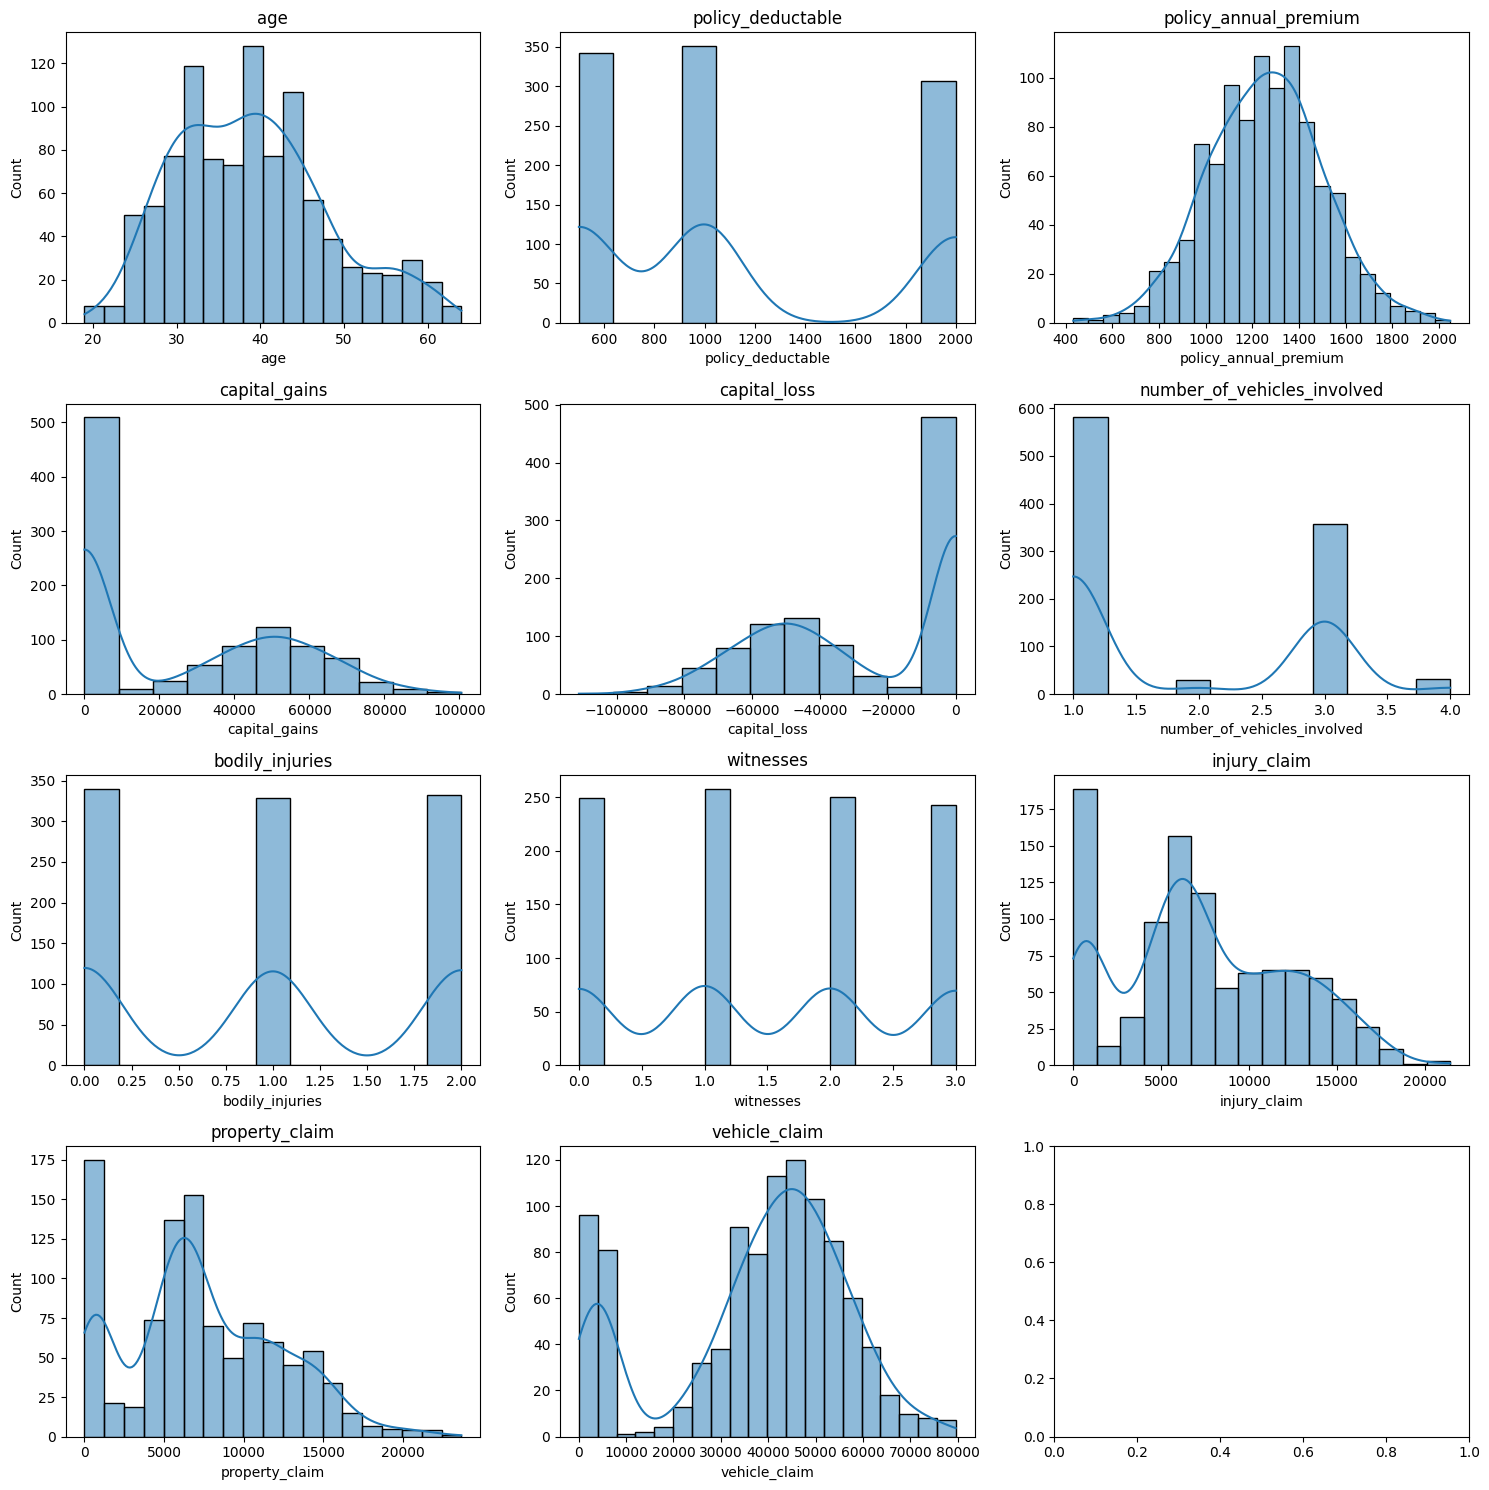

In [34]:
numericals=['age', 'policy_deductable', 'policy_annual_premium', 'capital_gains', 'capital_loss', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'injury_claim', 'property_claim', 'vehicle_claim']

# Standardize the data
# plot distribution of numericals
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#subplots distplot
fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.ravel()
for i, col in enumerate(numericals):
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [37]:
#policy_annual_premium min/max scaling
from sklearn.preprocessing import MinMaxScaler
minmax_scaler = MinMaxScaler()
df['policy_annual_premium'] = minmax_scaler.fit_transform(df[['policy_annual_premium']])

#scale numericals except policy_annual_premium
numericals=['age', 'policy_deductable', 'capital_gains', 'capital_loss', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses','injury_claim', 'property_claim', 'vehicle_claim']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[numericals] = scaler.fit_transform(df[numericals])


In [ ]:
#df.to_csv('insurance_claims_clean.csv')
#X_train.to_csv("X_train_1.csv")
#X_test.to_csv("X_test_1.csv")

In [38]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
age,0.990836,0.334073,-1.088913,0.224613,0.552994,0.005692,-0.541611,-0.213229,-0.651071,0.334073,...,0.443534,0.552994,-1.417295,-1.198374,-0.979453,-0.103769,0.224613,-0.541611,2.523284,2.304363
policy_bind_date,2014-10-17 00:00:00,2006-06-27 00:00:00,2000-09-06 00:00:00,1990-05-25 00:00:00,2014-06-06 00:00:00,2006-10-12 00:00:00,2000-06-04 00:00:00,1990-02-03 00:00:00,1997-02-05 00:00:00,2011-07-25 00:00:00,...,1994-02-05 00:00:00,2006-07-12 00:00:00,2007-10-24 00:00:00,2001-12-08 00:00:00,2007-03-24 00:00:00,1991-07-16 00:00:00,2014-01-05 00:00:00,2003-02-17 00:00:00,2011-11-18 00:00:00,1996-11-11 00:00:00
policy_state,2,1,2,0,0,2,1,0,0,0,...,0,2,1,2,1,2,0,2,0,2
policy_csl,1,1,0,1,2,1,1,0,0,0,...,0,0,0,1,2,2,0,1,2,1
policy_deductable,-0.222383,1.412784,1.412784,1.412784,-0.222383,-0.222383,-0.222383,-0.222383,-1.039966,-1.039966,...,-1.039966,-0.222383,-1.039966,-0.222383,-0.222383,-0.222383,-0.222383,-1.039966,1.412784,-0.222383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
incident_state_VA,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
incident_state_WV,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
police_report_available_NO,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
police_report_available_Unknown,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0


In [39]:
df_num=df[numericals]
df_num.T

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
age,0.990836,0.334073,-1.088913,0.224613,0.552994,0.005692,-0.541611,-0.213229,-0.651071,0.334073,...,0.443534,0.552994,-1.417295,-1.198374,-0.979453,-0.103769,0.224613,-0.541611,2.523284,2.304363
policy_deductable,-0.222383,1.412784,1.412784,1.412784,-0.222383,-0.222383,-0.222383,-0.222383,-1.039966,-1.039966,...,-1.039966,-0.222383,-1.039966,-0.222383,-0.222383,-0.222383,-0.222383,-1.039966,1.412784,-0.222383
capital_gains,1.011331,-0.901927,0.358023,0.853388,1.467210,-0.901927,-0.901927,-0.901927,-0.901927,-0.901927,...,1.880014,1.230296,0.903643,-0.901927,-0.901927,-0.901927,1.643100,0.358023,-0.901927,-0.901927
capital_loss,0.953851,0.953851,0.953851,-1.267577,-0.683741,0.953851,-1.787335,0.953851,0.953851,-0.445222,...,-0.213823,-0.192463,0.953851,-0.188903,-1.968894,0.953851,0.953851,0.953851,0.953851,0.953851
number_of_vehicles_involved,-0.823865,-0.823865,1.140056,-0.823865,-0.823865,1.140056,1.140056,1.140056,-0.823865,-0.823865,...,-0.823865,-0.823865,1.140056,1.140056,-0.823865,-0.823865,-0.823865,1.140056,-0.823865,-0.823865
bodily_injuries,0.009759,-1.210174,1.229693,0.009759,-1.210174,-1.210174,-1.210174,1.229693,0.009759,1.229693,...,1.229693,-1.210174,0.009759,-1.210174,0.009759,-1.210174,1.229693,1.229693,-1.210174,-1.210174
witnesses,0.461838,-1.338700,1.362107,0.461838,-0.438431,0.461838,-1.338700,0.461838,-0.438431,-0.438431,...,0.461838,-0.438431,0.461838,-0.438431,0.461838,-0.438431,1.362107,1.362107,-0.438431,1.362107
injury_claim,-0.189283,-1.363822,0.054644,-0.224130,-1.257232,-0.209781,2.873127,0.399011,-0.955911,-0.560298,...,-0.742731,-1.523707,-0.771428,-0.289724,-1.413017,2.051155,2.182342,0.013648,-0.453708,-1.429416
property_claim,1.165505,-1.372696,-0.736072,-0.219722,-1.399654,-0.205206,-0.051753,0.410680,-0.960031,-0.559808,...,-0.744367,-0.451976,-0.012353,-0.286081,-1.310485,0.273817,2.214794,0.020826,-0.451976,-1.343664
vehicle_claim,0.749653,-1.823346,-0.785565,0.677607,-1.768252,0.707273,0.642113,-0.270117,-0.835361,-0.266409,...,-0.596444,0.202950,-0.648359,0.541990,-1.751830,1.224309,1.821868,0.771902,-0.073580,-1.814340


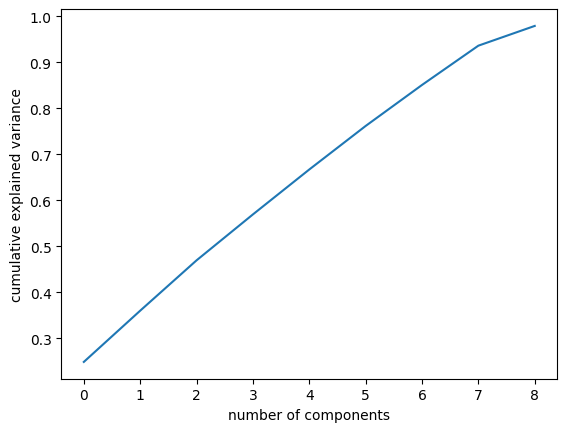

[0.24856981 0.11137474 0.10941412 0.09983326 0.09763599 0.0946146
 0.0891331  0.08540645 0.04292167]
[0.24856981 0.35994456 0.46935868 0.56919193 0.66682792 0.76144252
 0.85057563 0.93598208 0.97890375]


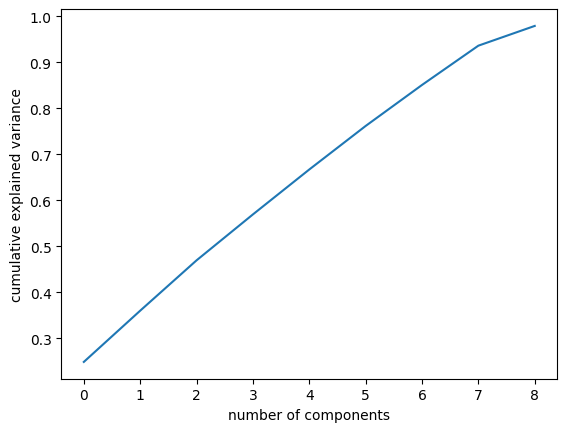

In [44]:
#pca with df_num
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit(df_num)
df_pca = pca.transform(df_num)
df_pca = pd.DataFrame(df_pca, columns=[f"PC{i+1}" for i in range(pca.n_components_)])
#explained pca variance
explained_variance = pca.explained_variance_
#plot explained variance
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()

#Display the explained variance ratio using PCA's explained_variance_ratio_ attribute for each component.
 #Plot the cumulative sum graph representing the explained variance ratio according to the number of components.
print(pca.explained_variance_ratio_)
print(np.cumsum(pca.explained_variance_ratio_))

#plot cumsum graph  
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()


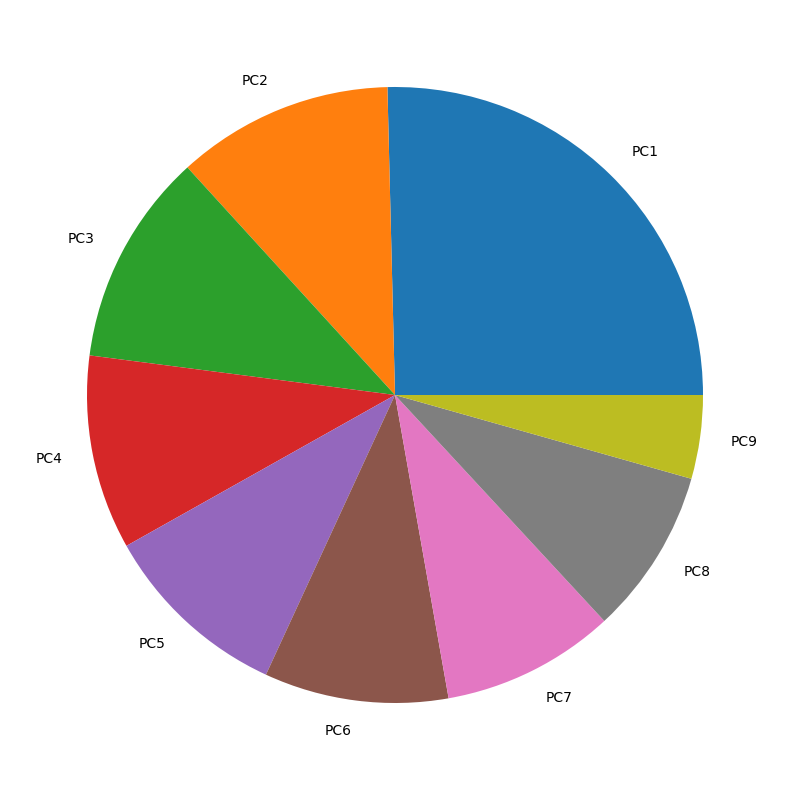

In [45]:
# piechart of explained variance ratio for each pca
plt.figure(figsize=(10, 10))
plt.pie(pca.explained_variance_ratio_, labels=[f"PC{i+1}" for i in range(pca.n_components_)])
plt.show()